# TrAISformer — reproducing the paper's evaluation
Runs the official CIA-Oceanix/TrAISformer repo end to end: same model, same CT-DMA dataset, same best-of-16 haversine-error test as the paper.

In [2]:
## Get repo (no git required)
import os, sys, urllib.request, zipfile

REPO_DIR = "TrAISformer"
if not os.path.isdir(REPO_DIR):
    zip_path = "traisformer_main.zip"
    urllib.request.urlretrieve(
        "https://github.com/CIA-Oceanix/TrAISformer/archive/refs/heads/main.zip", zip_path)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(".")
    os.rename("TrAISformer-main", REPO_DIR)
    os.remove(zip_path)

sys.path.insert(0, os.path.abspath(REPO_DIR))
os.chdir(REPO_DIR)
print("Working directory:", os.getcwd())


Working directory: C:\Users\dimit\Documents\MSML612\TrAISformer


In [3]:
# Patch known repo bugs (old removed/deprecated PyTorch & Matplotlib API)
trainers_path = "trainers.py"
with open(trainers_path, "r", encoding="utf-8") as f:
    src = f.read()

patched = src.replace(
    'seqs, masks, seqlens, mmsis, time_starts = iter(aisdls["test"]).next()',
    'seqs, masks, seqlens, mmsis, time_starts = next(iter(aisdls["test"]))'
).replace(
    'cmap = plt.cm.get_cmap("jet")',
    'cmap = plt.get_cmap("jet")'
)

if patched != src:
    with open(trainers_path, "w", encoding="utf-8") as f:
        f.write(patched)
    print("Patched trainers.py.")


In [4]:
# Dependencies
import torch
print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())


Torch: 2.12.1+cu126 | CUDA available: True


In [5]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm

import models, trainers, datasets, utils
from config_trAISformer import Config


## Config

In [6]:
QUICK_TEST = False  # False = paper's full 50-epoch run

cf = Config()
cf.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if cf.device.type == "cpu":
    print("WARNING: no GPU detected, training will be slow.")

cf.max_epochs = 10 if QUICK_TEST else cf.max_epochs
cf.retrain = True  # False + set cf.ckpt_path to skip training

# Override the region-of-interest for the custom Mid-Atlantic dataset
# (Config defaults to the paper's Danish CT-DMA bbox: lat 55.5-58.0, lon 10.3-13)
cf.lat_min, cf.lat_max = 36.51, 38.69
cf.lon_min, cf.lon_max = -77.35, -74.19

print("Run name:", cf.filename)
print("Checkpoint path:", cf.ckpt_path)

Run name: ct_dma-pos-pos_vicinity-10-40-blur-True-False-2-1.0-data_size-250-270-30-72-embd_size-256-256-128-128-head-8-8-bs-32-lr-0.0006-seqlen-18-120
Checkpoint path: ./results/ct_dma-pos-pos_vicinity-10-40-blur-True-False-2-1.0-data_size-250-270-30-72-embd_size-256-256-128-128-head-8-8-bs-32-lr-0.0006-seqlen-18-120/model.pt


In [7]:
# Determinism
utils.set_seed(42)
torch.pi = torch.acos(torch.zeros(1)).item() * 2


In [8]:
# Logging / output directory
os.makedirs(cf.savedir, exist_ok=True)
utils.new_log(cf.savedir, "log")

## Data

In [9]:
# Load + preprocess (identical to trAISformer.py)
init_seqlen = cf.init_seqlen
moving_threshold = 0.05
l_pkl_filenames = [cf.trainset_name, cf.validset_name, cf.testset_name]
Data, aisdatasets, aisdls = {}, {}, {}

for phase, filename in zip(("train", "valid", "test"), l_pkl_filenames):
    datapath = os.path.join(cf.datadir, filename)
    with open(datapath, "rb") as f:
        l_pred_errors = pickle.load(f)
    for V in l_pred_errors:
        try:
            moving_idx = np.where(V["traj"][:, 2] > moving_threshold)[0][0]
        except IndexError:
            moving_idx = len(V["traj"]) - 1  # filtered out below
        V["traj"] = V["traj"][moving_idx:, :]
    Data[phase] = [x for x in l_pred_errors if not np.isnan(x["traj"]).any() and len(x["traj"]) > cf.min_seqlen]
    print(f"{phase}: {len(l_pred_errors)} raw -> {len(Data[phase])} kept")

    if cf.mode in ("pos_grad", "grad"):
        aisdatasets[phase] = datasets.AISDataset_grad(Data[phase], max_seqlen=cf.max_seqlen + 1, device=cf.device)
    else:
        aisdatasets[phase] = datasets.AISDataset(Data[phase], max_seqlen=cf.max_seqlen + 1, device=cf.device)

    aisdls[phase] = torch.utils.data.DataLoader(aisdatasets[phase], batch_size=cf.batch_size, shuffle=phase != "test")

cf.final_tokens = 2 * len(aisdatasets["train"]) * cf.max_seqlen


train: 10605 raw -> 9144 kept
valid: 1481 raw -> 1291 kept
test: 1593 raw -> 1453 kept


## Model + Trainer

In [10]:
# Model
model = models.TrAISformer(cf, partition_model=None)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


2026-08-19 17:23:05,748 - models - number of parameters: 5.742055e+07


Model parameters: 57,420,547


In [11]:
# Trainer
trainer = trainers.Trainer(
    model, aisdatasets["train"], aisdatasets["valid"], cf,
    savedir=cf.savedir, device=cf.device, aisdls=aisdls, INIT_SEQLEN=init_seqlen
)


## Train

In [12]:
if cf.retrain:
    trainer.train()


epoch 1 iter 285: loss 4.91077. lr 5.993205e-04: 100%|██████████| 286/286 [00:48<00:00,  5.86it/s] 
2026-08-19 17:24:05,761 - root - Training, epoch 1, loss 9.61532, lr 5.993205e-04.
2026-08-19 17:24:17,884 - root - Valid, epoch 1, loss 4.65149.
2026-08-19 17:24:17,886 - root - Best epoch: 001, saving model to ./results/ct_dma-pos-pos_vicinity-10-40-blur-True-False-2-1.0-data_size-250-270-30-72-embd_size-256-256-128-128-head-8-8-bs-32-lr-0.0006-seqlen-18-120/model.pt
epoch 2 iter 285: loss 2.96846. lr 5.966600e-04: 100%|██████████| 286/286 [00:47<00:00,  5.96it/s]
2026-08-19 17:25:16,311 - root - Training, epoch 2, loss 3.01061, lr 5.966600e-04.
2026-08-19 17:25:28,018 - root - Valid, epoch 2, loss 2.48535.
2026-08-19 17:25:28,022 - root - Best epoch: 002, saving model to ./results/ct_dma-pos-pos_vicinity-10-40-blur-True-False-2-1.0-data_size-250-270-30-72-embd_size-256-256-128-128-head-8-8-bs-32-lr-0.0006-seqlen-18-120/model.pt
epoch 3 iter 285: loss 2.01862. lr 5.920037e-04: 100%|███

## Evaluate — best-of-16 haversine error at 1h/2h/3h (the paper's test)

In [26]:
# Load best checkpoint + run test-set evaluation
model.load_state_dict(torch.load(cf.ckpt_path, map_location=cf.device))

# Derived from the model's actual ROI (cf.lat_min/lat_max/lon_min/lon_max) instead of
# the CT-DMA-specific hard-coded constants in the official repo's trAISformer.py
v_ranges = torch.tensor([model.lat_range, model.lon_range, 0, 0]).to(cf.device)
v_roi_min = torch.tensor([model.lat_min, model.lon_min, 0, 0]).to(cf.device)
max_seqlen = init_seqlen + 6 * 10  # 10h future horizon at 10-min resolution

model.eval()
l_min_errors, l_mean_errors, l_masks = [], [], []
pbar = tqdm(enumerate(aisdls["test"]), total=len(aisdls["test"]))

with torch.no_grad():
    for it, (seqs, masks, seqlens, mmsis, time_starts) in pbar:
        seqs_init = seqs[:, :init_seqlen, :].to(cf.device)
        masks = masks[:, :max_seqlen].to(cf.device)
        batchsize = seqs.shape[0]
        error_ens = torch.zeros((batchsize, max_seqlen - cf.init_seqlen, cf.n_samples)).to(cf.device)

        for i_sample in range(cf.n_samples):
            preds = trainers.sample(
                model, seqs_init, max_seqlen - init_seqlen,
                temperature=1.0, sample=True,
                sample_mode=cf.sample_mode, r_vicinity=cf.r_vicinity, top_k=cf.top_k
            )
            inputs = seqs[:, :max_seqlen, :].to(cf.device)
            input_coords = (inputs * v_ranges + v_roi_min) * torch.pi / 180
            pred_coords = (preds * v_ranges + v_roi_min) * torch.pi / 180
            d = utils.haversine(input_coords, pred_coords) * masks
            error_ens[:, :, i_sample] = d[:, cf.init_seqlen:]

        # error_ens: (batch, T, 16) -- one haversine error per path, per timestep, per sample
        l_min_errors.append(error_ens.min(dim=-1))    # best-of-16, per path
        l_mean_errors.append(error_ens.mean(dim=-1))  # mean-of-16, per path
        l_masks.append(masks[:, cf.init_seqlen:])

l_min = [x.values for x in l_min_errors]
l_mean = [x for x in l_mean_errors]
m_masks = torch.cat(l_masks, dim=0)

min_errors = torch.cat(l_min, dim=0) * m_masks
mean_errors = torch.cat(l_mean, dim=0) * m_masks

# "Best of 16" -- closest of the 16 sampled predictions to ground truth, per path, averaged over the test set
pred_errors = (min_errors.sum(dim=0) / m_masks.sum(dim=0)).detach().cpu().numpy()

# "Mean of 16" -- average error across all 16 sampled predictions, per path, averaged over the test set
mean_pred_errors = (mean_errors.sum(dim=0) / m_masks.sum(dim=0)).detach().cpu().numpy()

100%|██████████| 46/46 [17:48<00:00, 23.23s/it]


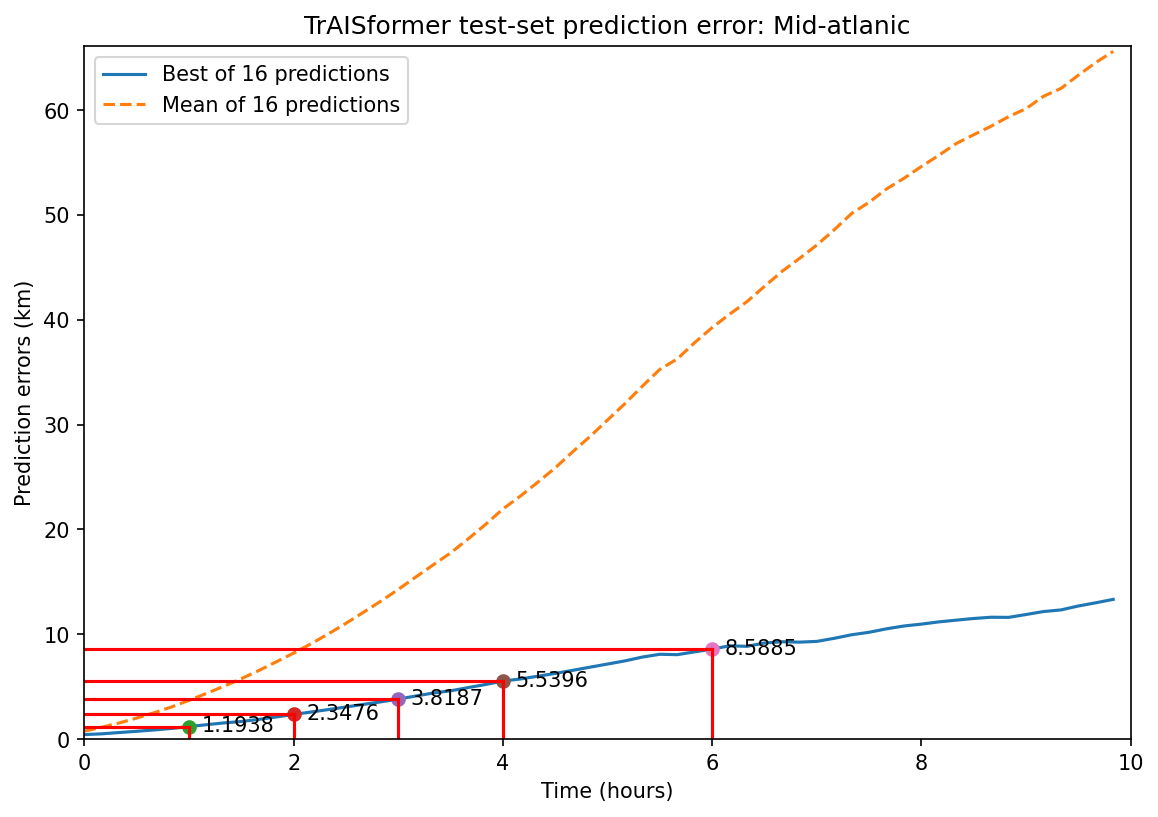

In [32]:
# Plot -- error vs. time: best-of-16 (paper's metric) vs. mean-of-16
plt.figure(figsize=(9, 6), dpi=150)
v_times = np.arange(len(pred_errors)) / 6
plt.plot(v_times, pred_errors, label=f"Best of {cf.n_samples} predictions")
plt.plot(v_times, mean_pred_errors, "--", label=f"Mean of {cf.n_samples} predictions")

for timestep, hour in [(6, 1), (12, 2), (18, 3), (24, 4), (36, 6), (60, 10)]:
    if timestep < len(pred_errors):
        plt.plot(hour, pred_errors[timestep], "o")
        plt.plot([hour, hour], [0, pred_errors[timestep]], "r")
        plt.plot([0, hour], [pred_errors[timestep], pred_errors[timestep]], "r")
        plt.text(hour + 0.12, pred_errors[timestep] - 0.5, f"{pred_errors[timestep]:.4f}", fontsize=10)

plt.xlabel("Time (hours)")
plt.ylabel("Prediction errors (km)")
plt.xlim([0, 10])
plt.ylim([0, max(20, mean_pred_errors.max() + 0.5)])
plt.title("TrAISformer test-set prediction error: Mid-atlanic")
plt.legend()
plt.savefig(os.path.join(cf.savedir, "prediction_error.png"))
plt.show()

In [33]:
# Same numbers in nautical miles -- best-of-16 and mean-of-16 side by side
KM_TO_NMI = 0.539957
print(f"{'Horizon':>10} | {'best-of-16 (km)':>16} | {'best-of-16 (nmi)':>17} | {'mean-of-16 (km)':>16} | {'mean-of-16 (nmi)':>17}")
for timestep, hour in [(6, 1), (12, 2), (18, 3), (24, 4), (36, 6), (60, 10)]:
    if timestep < len(pred_errors):
        best_km, mean_km = pred_errors[timestep], mean_pred_errors[timestep]
        print(f"{hour:>9}h | {best_km:16.4f} | {best_km * KM_TO_NMI:17.4f} | {mean_km:16.4f} | {mean_km * KM_TO_NMI:17.4f}")

   Horizon |  best-of-16 (km) |  best-of-16 (nmi) |  mean-of-16 (km) |  mean-of-16 (nmi)
        1h |           1.1938 |            0.6446 |           3.6964 |            1.9959
        2h |           2.3476 |            1.2676 |           8.2057 |            4.4307
        3h |           3.8187 |            2.0619 |          14.2827 |            7.7121
        4h |           5.5396 |            2.9911 |          21.9574 |           11.8561
        6h |           8.5885 |            4.6374 |          39.2674 |           21.2027


## Per-attribute accuracy (teacher-forced)

In [34]:
model.eval()
correct = {"lat": 0, "lon": 0, "sog": 0, "cog": 0}
total = 0

with torch.no_grad():
    for it, (seqs, masks, seqlens, mmsis, time_starts) in tqdm(enumerate(aisdls["test"]), total=len(aisdls["test"])):
        seqs = seqs.to(cf.device)
        masks = masks[:, :-1].to(cf.device)  # with_targets=True shifts by one step

        idxs, _ = model.to_indexes(seqs, mode=model.partition_mode)
        targets = idxs[:, 1:, :].contiguous()

        logits, _ = model(seqs, masks=masks, with_targets=True)
        lat_logits, lon_logits, sog_logits, cog_logits = torch.split(
            logits, (model.lat_size, model.lon_size, model.sog_size, model.cog_size), dim=-1
        )
        preds = {
            "lat": lat_logits.argmax(dim=-1), "lon": lon_logits.argmax(dim=-1),
            "sog": sog_logits.argmax(dim=-1), "cog": cog_logits.argmax(dim=-1),
        }
        for i, key in enumerate(["lat", "lon", "sog", "cog"]):
            correct[key] += ((preds[key] == targets[:, :, i]).float() * masks).sum().item()
        total += masks.sum().item()

print(f"{'Attribute':>10} | {'Top-1 accuracy':>15}")
for key in ["lat", "lon", "sog", "cog"]:
    print(f"{key:>10} | {correct[key] / total * 100:14.2f}%")


100%|██████████| 46/46 [00:02<00:00, 16.52it/s]

 Attribute |  Top-1 accuracy
       lat |          74.66%
       lon |          68.24%
       sog |          75.76%
       cog |          55.13%


## Trajectory plot

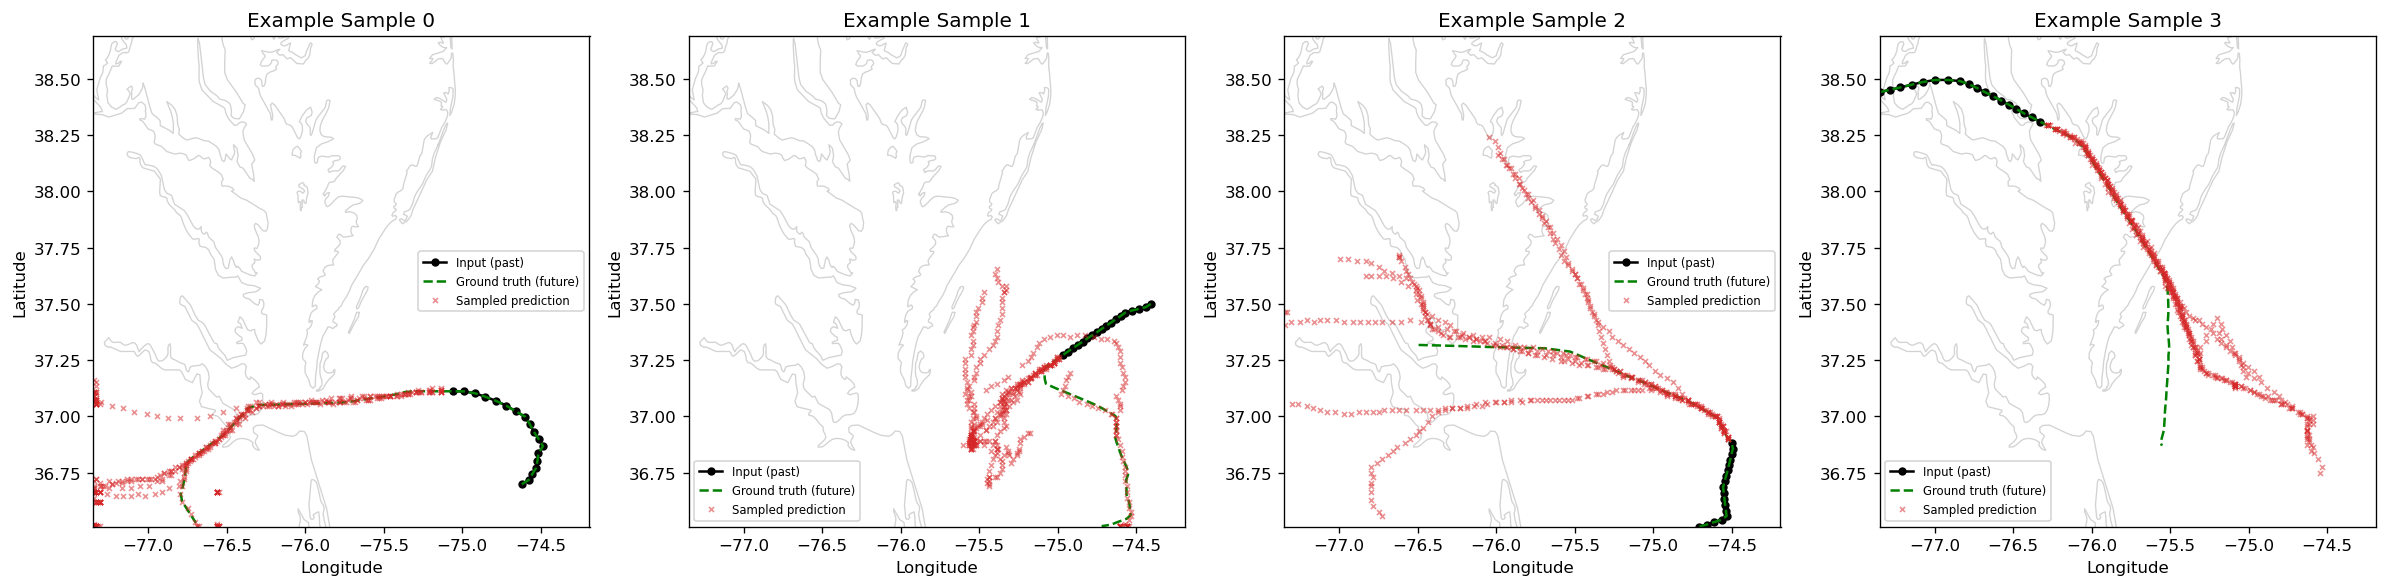

In [35]:
with open(os.path.join(cf.datadir, "chesapeake_coastline_polygons.pkl"), "rb") as f:
    coastline_polygons = pickle.load(f)

def to_latlon(x):
    lat = x[..., 0] * model.lat_range + model.lat_min
    lon = x[..., 1] * model.lon_range + model.lon_min
    return lat, lon

model.eval()
n_plots = 4
n_samples_to_show = 8

seqs, masks, seqlens, mmsis, time_starts = next(iter(aisdls["test"]))
seqs_init = seqs[:n_plots, :init_seqlen, :].to(cf.device)

with torch.no_grad():
    all_preds = torch.stack([
        trainers.sample(model, seqs_init, max_seqlen - init_seqlen, temperature=1.0, sample=True,
                         sample_mode=cf.sample_mode, r_vicinity=cf.r_vicinity, top_k=cf.top_k)
        for _ in range(n_samples_to_show)
    ])

seqs_np = seqs[:n_plots, :max_seqlen, :].cpu().numpy()
preds_np = all_preds.cpu().numpy()

fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5), dpi=120)
if n_plots == 1:
    axes = [axes]

for idx, ax in enumerate(axes):
    seqlen = min(seqlens[idx].item(), max_seqlen)

    for poly in coastline_polygons:
        ax.plot(poly[:, 1], poly[:, 0], color="lightgray", linewidth=0.8, zorder=0)

    lat_in, lon_in = to_latlon(seqs_np[idx][:init_seqlen])
    ax.plot(lon_in, lat_in, "o-", color="black", markersize=4, label="Input (past)")

    lat_true, lon_true = to_latlon(seqs_np[idx][:seqlen])
    ax.plot(lon_true, lat_true, "--", color="green", linewidth=1.5, label="Ground truth (future)")

    for s in range(n_samples_to_show):
        lat_p, lon_p = to_latlon(preds_np[s, idx][init_seqlen:])
        ax.plot(lon_p, lat_p, "x", markersize=3, alpha=0.5, color="tab:red",
                 label="Sampled prediction" if s == 0 else None)

    ax.set_xlim(model.lon_min, model.lon_max)
    ax.set_ylim(model.lat_min, model.lat_max)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"Example Sample {idx}")
    ax.legend(fontsize=7, loc="best")

plt.tight_layout()
plt.savefig(os.path.join(cf.savedir, "trajectory_predictions.png"))
plt.show()

## Loss curves

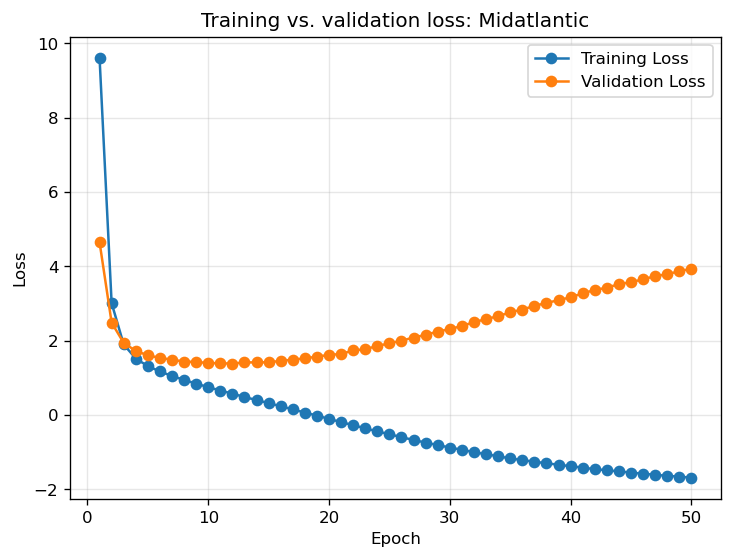

In [36]:
import logging, re

log_file = [h for h in logging.getLogger("").handlers if hasattr(h, "baseFilename")][0].baseFilename
with open(log_file, "r") as f:
    log_lines = f.readlines()

train_losses, valid_losses = {}, {}
for line in log_lines:
    m = re.search(r"Training, epoch (\d+), loss (-?\d+\.\d+)", line)
    if m:
        train_losses[int(m.group(1))] = float(m.group(2))
    m = re.search(r"Valid, epoch (\d+), loss (\d+\.\d+)", line)
    if m:
        valid_losses[int(m.group(1))] = float(m.group(2))

train_epochs, valid_epochs = sorted(train_losses), sorted(valid_losses)

plt.figure(figsize=(7, 5), dpi=120)
plt.plot(train_epochs, [train_losses[e] for e in train_epochs], "o-", label="Training Loss")
plt.plot(valid_epochs, [valid_losses[e] for e in valid_epochs], "o-", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs. validation loss: Midatlantic")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(os.path.join(cf.savedir, "loss_curves.png"))
plt.show()
